## 0 — Install (run once, then restart runtime)

In [1]:
!python -m pip install -U pip
!python -m pip install "scipy>=1.14.1"

## 1 — Config & Drive

In [2]:
import os, json, warnings, numpy as np, torch
warnings.filterwarnings("ignore")

PRIMARY_CSV_PATH = "primary.csv"
TEXT_COL  = "text"
LABEL_COL = "category"

CFG = {
    "max_length"         : 128,
    "primary_num_labels" : 7,
    "n_folds"            : 5,
    "seed"               : 42,
    "output_dir"         : "output",
    "device"             : "cuda" if torch.cuda.is_available() else "cpu",
    "deberta_model"      : "microsoft/deberta-v3-base",
    "mpnet_model"        : "sentence-transformers/all-mpnet-base-v2",
    "setfit_model"       : "sentence-transformers/paraphrase-mpnet-base-v2",
    "lora_r"             : 16,
    "lora_alpha"         : 32,
    "lora_dropout"       : 0.1,
    "primary_epochs"     : 5,
    "primary_lr"         : 2e-4,
    "primary_batch_size" : 16,
    "probe_epochs"       : 10,
    "probe_lr"           : 1e-3,
    "probe_batch_size"   : 32,
    "neural_epochs"      : 15,
    "neural_lr"          : 1e-3,
    "neural_batch_size"  : 32,
    "setfit_epochs"      : 1,
    "setfit_num_iters"   : 20,
    "ensemble_weights"   : [0.25, 0.45, 0.30],
}
os.makedirs(CFG["output_dir"], exist_ok=True)
torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
print(f"✅ Device: {CFG['device']}")

✅ Device: cpu


## 2 — Imports

In [3]:
!pip uninstall -y transformers setfit sentence-transformers huggingface-hub
!pip install "setfit==1.1.3" "transformers<5" "sentence-transformers<5"

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
Found existing installation: setfit 1.1.3
Uninstalling setfit-1.1.3:
  Successfully uninstalled setfit-1.1.3
Found existing installation: sentence-transformers 4.1.0
Uninstalling sentence-transformers-4.1.0:
  Successfully uninstalled sentence-transformers-4.1.0
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
  Using cached setfit-1.1.3-py3-none-any.whl.metadata (12 kB)
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached sentence_transformers-4.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
Using cached setfit-1.1.3-py3-none-any.whl (75 kB)
Using cached transformers-4.57.6-py3-none-any.whl (12.0 MB)
Using cached sentence_transformers-4.1.0-py3-none-any.whl (345 kB)
Using cach

In [4]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType
from sentence_transformers import SentenceTransformer
from setfit import SetFitModel, SetFitTrainer
from datasets import load_dataset, Dataset as HFDataset
print("✅ Imports OK")

✅ Imports OK


## 3 — Shared Utilities

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.enc = tokenizer(texts, truncation=True, padding="max_length",
                             max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

class LinearProbe(nn.Module):
    def __init__(self, in_dim, num_labels):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_labels)
    def forward(self, x): return self.fc(x)

def make_result(name, accs, f1s):
    return dict(
        dataset=name,
        accuracy_mean=round(float(np.mean(accs)), 4),
        accuracy_std =round(float(np.std(accs)),  4),
        f1_mean      =round(float(np.mean(f1s)),  4),
        f1_std       =round(float(np.std(f1s)),   4),
        per_fold_acc =[round(a,4) for a in accs],
        per_fold_f1  =[round(f,4) for f in f1s],
    )

def print_result(model_name, ds_name, r):
    folds = r.get("per_fold_acc", [])
    fold_str = "  ".join([f"F{i+1}:{v:.4f}" for i,v in enumerate(folds)])
    print(f"  ► [{model_name}] {ds_name}: "
          f"acc={r['accuracy_mean']:.4f}±{r['accuracy_std']:.4f}  "
          f"f1={r['f1_mean']:.4f}±{r['f1_std']:.4f}")
    print(f"    Per-fold acc: {fold_str}")

print("✅ Utilities ready")

✅ Utilities ready


## 4 — Load Primary Dataset

In [6]:
df = pd.read_csv(PRIMARY_CSV_PATH)
print(f"Loaded: {len(df)} rows | columns: {df.columns.tolist()}")
print(df[LABEL_COL].value_counts().sort_index())

primary_texts = df[TEXT_COL].astype(str).tolist()
le = LabelEncoder()
primary_labels = le.fit_transform(df[LABEL_COL].astype(str)).tolist()
CFG["primary_num_labels"] = len(le.classes_)
assert len(set(primary_labels)) == CFG["primary_num_labels"]
print(f"\n✅ {len(primary_texts)} samples, {len(set(primary_labels))} classes")

Loaded: 959 rows | columns: ['text', 'category']
category
Career Preparation             98
Extracurricular Activities    195
Facilities and Resources       88
Improvement Suggestions       202
Social Experience              86
Support Services               93
Teaching Quality              197
Name: count, dtype: int64

✅ 959 samples, 7 classes


## 5 — Load Target Datasets

In [7]:
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

def load_edura():
    ds    = load_dataset("yhua219/EduRABSA_SA")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]
    
    # Print columns so we can verify
    print(f"EduRABSA columns: {data.column_names}")
    
    texts  = [str(t) for t in data["text"]]
    
    # Try "output" first, fall back to other common names
    if "output" in data.column_names:
        raw_lb = [str(l).strip() for l in data["output"]]
    elif "sentiment" in data.column_names:
        raw_lb = [str(l).strip() for l in data["sentiment"]]
    elif "label" in data.column_names:
        raw_lb = [str(l).strip() for l in data["label"]]
    else:
        # Use last column as fallback
        col = data.column_names[-1]
        print(f"  Using fallback column: {col}")
        raw_lb = [str(l).strip() for l in data[col]]
    
    pairs = [(t, l) for t, l in zip(texts, raw_lb) if l not in ("", "nan", "None")]
    if len(pairs) == 0:
        raise ValueError("EduRABSA: all labels are empty — check column names above")
    
    texts, raw_lb = zip(*pairs)
    le = LabelEncoder()
    labels = le.fit_transform(list(raw_lb)).tolist()
    print(f"EduRABSA  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), labels, le.classes_.tolist()


def load_coursera(max_samples=3999):
    ds    = load_dataset("MungunshagaiT/coursera-reviews")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]
    
    texts  = [str(t) for t in data["text"]]
    raw_lb = list(data["label"])
    unique = sorted(set(raw_lb))
    
    if set(unique) == {0, 1, 2}:
        mapping = {0: "Negative", 1: "Positive", 2: "Neutral"}
        raw_lb = [mapping[v] for v in raw_lb]
    elif set(unique) == {0, 1}:
        raw_lb = ["Negative" if v == 0 else "Positive" for v in raw_lb]
    elif min(unique) >= 1 and max(unique) <= 5:
        raw_lb = ["Positive" if v >= 4 else ("Neutral" if v == 3 else "Negative") for v in raw_lb]
    else:
        raw_lb = [str(v) for v in raw_lb]
    
    pairs = [(t, l) for t, l in zip(texts, raw_lb) if str(l).strip() != ""]
    texts, raw_lb = zip(*pairs)
    
    le = LabelEncoder()
    labels_all = le.fit_transform(list(raw_lb)).tolist()
    
    if len(texts) > max_samples:
        texts, _, labels_all, _ = train_test_split(
            list(texts), labels_all, train_size=max_samples,
            random_state=CFG["seed"], stratify=labels_all)
    
    print(f"Coursera  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), list(labels_all), le.classes_.tolist()


# ── Load datasets ──────────────────────────────────────────
print("Loading target datasets...")
edura_texts,    edura_labels,    edura_classes    = load_edura()
coursera_texts, coursera_labels, coursera_classes = load_coursera(max_samples=10000)

TARGET_DATASETS = [
    ("EduRABSA", edura_texts,    edura_labels,    len(edura_classes)),
    ("Coursera", coursera_texts, coursera_labels, len(coursera_classes)),
]
print("\n✅ Target datasets ready")
print(f"   EduRABSA: {len(edura_texts)} samples | {edura_classes}")
print(f"   Coursera: {len(coursera_texts)} samples | {coursera_classes}")

# ── Class distribution ─────────────────────────────────────
for ds_name, texts, labels, classes in TARGET_DATASETS:
    # FIX: 'classes' is a list of names, not an integer
    class_names = edura_classes if ds_name == "EduRABSA" else coursera_classes
    counter = Counter(labels)
    total = len(labels)
    print(f"\n📊 {ds_name} class distribution ({total} samples):")
    for idx, cls_name in enumerate(class_names):  # FIX: iterate list not range
        count = counter.get(idx, 0)
        pct = count / total * 100
        bar = "█" * int(pct / 2)
        print(f"   {cls_name:<12} : {count:>5} samples ({pct:5.1f}%)  {bar}")

Loading target datasets...
EduRABSA columns: ['id', 'task_type', 'original_id', 'text', 'output']
EduRABSA  | 3999 samples | classes: ['negative', 'neutral', 'positive']
Coursera  | 10000 samples | classes: ['Negative', 'Neutral', 'Positive']

✅ Target datasets ready
   EduRABSA: 3999 samples | ['negative', 'neutral', 'positive']
   Coursera: 10000 samples | ['Negative', 'Neutral', 'Positive']

📊 EduRABSA class distribution (3999 samples):
   negative     :   954 samples ( 23.9%)  ███████████
   neutral      :   953 samples ( 23.8%)  ███████████
   positive     :  2092 samples ( 52.3%)  ██████████████████████████

📊 Coursera class distribution (10000 samples):
   Negative     :   441 samples (  4.4%)  ██
   Neutral      :  4543 samples ( 45.4%)  ██████████████████████
   Positive     :  5016 samples ( 50.2%)  █████████████████████████


## 6 — Classical Protocol

In [8]:
def sklearn_5fold_cv(texts, labels, pipeline_factory, num_labels, ds_name, model_name, cfg):
    labels_arr = np.array(labels)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    accs, f1s = [], []
    print(f"  [{model_name}] 5-fold CV on {ds_name} ({len(labels)} samples, {num_labels} classes)")
    for fold, (tri, tei) in enumerate(skf.split(texts, labels_arr), 1):
        X_tr = [texts[i] for i in tri]; y_tr = labels_arr[tri]
        X_te = [texts[i] for i in tei]; y_te = labels_arr[tei]
        pipeline = pipeline_factory()
        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_te)
        accs.append(accuracy_score(y_te, preds))
        f1s.append(f1_score(y_te, preds, average="macro", zero_division=0))
        print(f"    Fold {fold}: acc={accs[-1]:.4f}  f1={f1s[-1]:.4f}")
    r = make_result(ds_name, accs, f1s)
    print_result(model_name, ds_name, r)
    return r
print("✅ Classical protocol defined")

✅ Classical protocol defined


## 7 — Model 1: TF-IDF + LR

In [9]:
print("=" * 65)
print("MODEL 1: TF-IDF + LR/SVM  (Classical — native sklearn protocol)")
print("=" * 65)

# Add n_folds to the CFG dictionary
CFG["n_folds"] = 5  # You can adjust this value based on your needs

def tfidf_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True)),
        ("clf",   LogisticRegression(max_iter=1000, C=1.0,
                                     class_weight="balanced",
                                     random_state=CFG["seed"])),
    ])

results_tfidf = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    results_tfidf[name] = sklearn_5fold_cv(
        texts, labels, tfidf_pipeline, n_cls, name, "TF-IDF+LR", CFG)
print("✅ TF-IDF done")

MODEL 1: TF-IDF + LR/SVM  (Classical — native sklearn protocol)
  [TF-IDF+LR] 5-fold CV on EduRABSA (3999 samples, 3 classes)
    Fold 1: acc=0.7462  f1=0.7160
    Fold 2: acc=0.7225  f1=0.7007
    Fold 3: acc=0.7325  f1=0.7039
    Fold 4: acc=0.7212  f1=0.6911
    Fold 5: acc=0.7247  f1=0.6866
  ► [TF-IDF+LR] EduRABSA: acc=0.7294±0.0093  f1=0.6997±0.0103
    Per-fold acc: F1:0.7462  F2:0.7225  F3:0.7325  F4:0.7212  F5:0.7247
  [TF-IDF+LR] 5-fold CV on Coursera (10000 samples, 3 classes)
    Fold 1: acc=0.4785  f1=0.5097
    Fold 2: acc=0.4855  f1=0.4980
    Fold 3: acc=0.4595  f1=0.4491
    Fold 4: acc=0.4815  f1=0.4893
    Fold 5: acc=0.5090  f1=0.5124
  ► [TF-IDF+LR] Coursera: acc=0.4828±0.0159  f1=0.4917±0.0228
    Per-fold acc: F1:0.4785  F2:0.4855  F3:0.4595  F4:0.4815  F5:0.5090
✅ TF-IDF done


## 8 — Model 2: Hybrid (TF-IDF + MiniLM)

In [10]:
print("=" * 65)
print("MODEL 2: Hybrid (TF-IDF + MiniLM Embeddings)")
print("=" * 65)

hybrid_sbert = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
results_hybrid = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    labels_arr = np.array(labels)
    skf = StratifiedKFold(n_splits=CFG["n_folds"], shuffle=True, random_state=CFG["seed"])
    accs, f1s = [], []
    print(f"  [Hybrid] 5-fold CV on {name} ({len(labels)} samples, {n_cls} classes)")
    for fold, (tri, tei) in enumerate(skf.split(texts, labels_arr), 1):
        X_tr_t = [texts[i] for i in tri]; y_tr = labels_arr[tri]
        X_te_t = [texts[i] for i in tei]; y_te = labels_arr[tei]
        tv = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)
        tfidf_tr = tv.fit_transform(X_tr_t)
        tfidf_te = tv.transform(X_te_t)
        emb_tr = csr_matrix(hybrid_sbert.encode(X_tr_t, batch_size=128, show_progress_bar=False))
        emb_te = csr_matrix(hybrid_sbert.encode(X_te_t, batch_size=128, show_progress_bar=False))
        feats_tr = hstack([tfidf_tr, emb_tr])
        feats_te = hstack([tfidf_te, emb_te])
        clf = LogisticRegression(max_iter=1000, C=1.0,
                         class_weight="balanced",
                         random_state=CFG["seed"])
        clf.fit(feats_tr, y_tr)
        preds = clf.predict(feats_te)
        accs.append(accuracy_score(y_te, preds))
        f1s.append(f1_score(y_te, preds, average="macro", zero_division=0))
        print(f"    Fold {fold}: acc={accs[-1]:.4f}  f1={f1s[-1]:.4f}")
    results_hybrid[name] = make_result(name, accs, f1s)
    print_result("Hybrid", name, results_hybrid[name])
print("\n✅ Hybrid done")

MODEL 2: Hybrid (TF-IDF + MiniLM Embeddings)
  [Hybrid] 5-fold CV on EduRABSA (3999 samples, 3 classes)
    Fold 1: acc=0.7625  f1=0.7326
    Fold 2: acc=0.7312  f1=0.7068
    Fold 3: acc=0.7450  f1=0.7194
    Fold 4: acc=0.7450  f1=0.7152
    Fold 5: acc=0.7359  f1=0.7018
  ► [Hybrid] EduRABSA: acc=0.7439±0.0107  f1=0.7152±0.0107
    Per-fold acc: F1:0.7625  F2:0.7312  F3:0.7450  F4:0.7450  F5:0.7359
  [Hybrid] 5-fold CV on Coursera (10000 samples, 3 classes)
    Fold 1: acc=0.4900  f1=0.5266
    Fold 2: acc=0.4975  f1=0.5178
    Fold 3: acc=0.4855  f1=0.5116
    Fold 4: acc=0.4855  f1=0.5160
    Fold 5: acc=0.5105  f1=0.5243
  ► [Hybrid] Coursera: acc=0.4938±0.0094  f1=0.5193±0.0055
    Per-fold acc: F1:0.4900  F2:0.4975  F3:0.4855  F4:0.4855  F5:0.5105

✅ Hybrid done


## 9 — Save Results

In [11]:
import json, os

# ── Make sure CFG is defined ──
if 'CFG' not in dir() or 'output_dir' not in CFG:
    CFG = {"output_dir": "primary_results", "seed": 42}
os.makedirs(CFG["output_dir"], exist_ok=True)

NOTEBOOK_TAG = "classical"
out = {
    "TF-IDF + LR/SVM":     results_tfidf,
    "Hybrid (TF-IDF+Emb)": results_hybrid,
}
out_path = f"{CFG['output_dir']}/results_{NOTEBOOK_TAG}.json"
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)
print(f"✅ Saved → {out_path}")

✅ Saved → output/results_classical.json


## 10 — Results Table


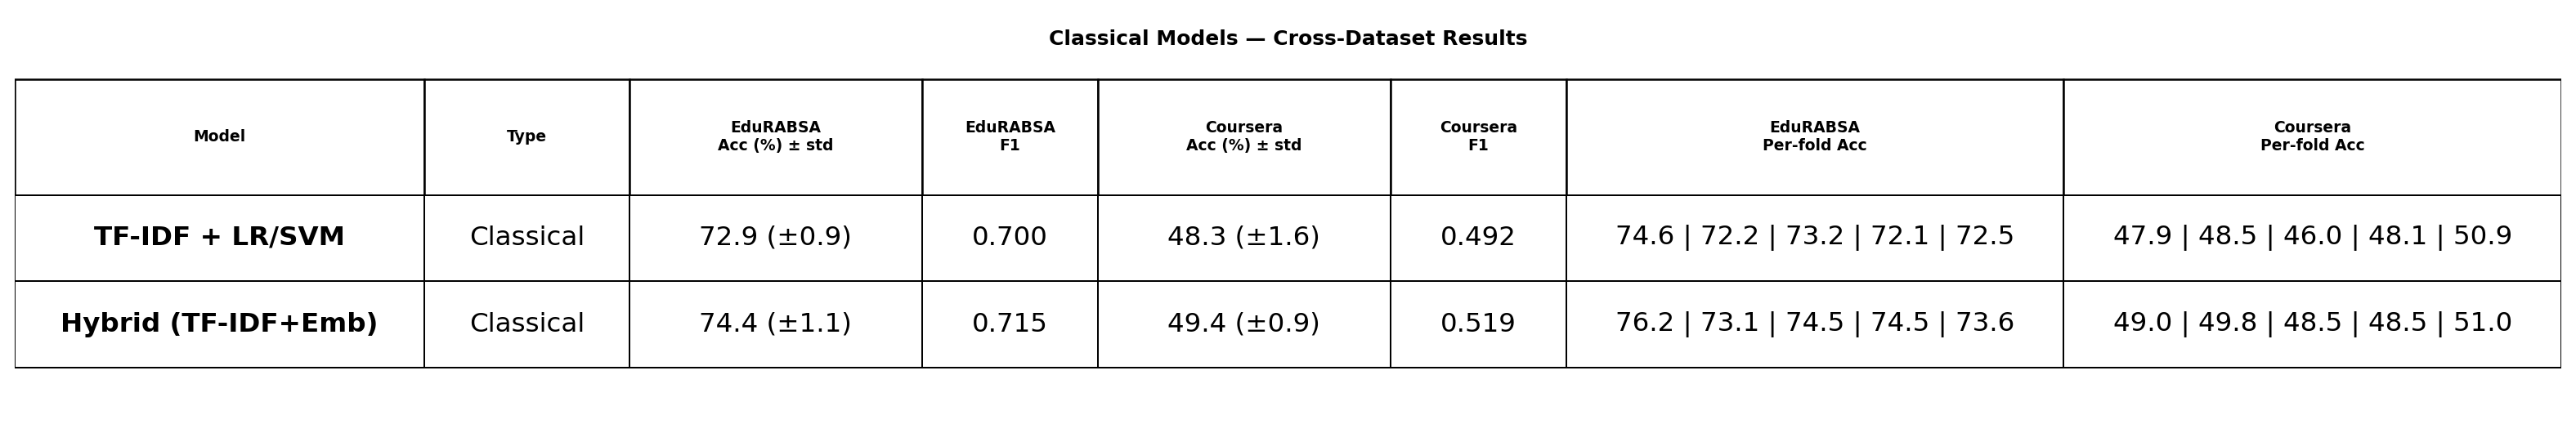

✅ Table saved → output/classical_results_table_simple.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

all_models = [
    ("TF-IDF + LR/SVM",     results_tfidf,  "Classical"),
    ("Hybrid (TF-IDF+Emb)", results_hybrid, "Classical"),
]

def fmt_acc(r):
    m = r.get("accuracy_mean", 0) * 100
    s = r.get("accuracy_std", 0) * 100
    return f"{m:.1f} (±{s:.1f})"

def fmt_f1(r):
    return f"{r.get('f1_mean', 0):.3f}"

def fmt_folds(r):
    folds = r.get("per_fold_acc", [])
    return " | ".join([f"{v*100:.1f}" for v in folds]) if folds else "—"

rows = []
for mname, rdict, group in all_models:
    edu = rdict.get("EduRABSA", {})
    cou = rdict.get("Coursera", {})

    rows.append({
        "model": mname,
        "group": group,
        "edu_acc": fmt_acc(edu),
        "edu_f1": fmt_f1(edu),
        "cou_acc": fmt_acc(cou),
        "cou_f1": fmt_f1(cou),
        "edu_folds": fmt_folds(edu),
        "cou_folds": fmt_folds(cou),
    })

col_labels = [
    "Model", "Type",
    "EduRABSA\nAcc (%) ± std", "EduRABSA\nF1",
    "Coursera\nAcc (%) ± std", "Coursera\nF1",
    "EduRABSA\nPer-fold Acc", "Coursera\nPer-fold Acc"
]

col_widths = [2.8, 1.4, 2.0, 1.2, 2.0, 1.2, 3.4, 3.4]
total_width = sum(col_widths)

row_h = 0.60
header_h = 0.80
title_h = 0.45
fig_h = title_h + header_h + len(rows) * row_h + 0.35

fig, ax = plt.subplots(figsize=(total_width, fig_h), dpi=180)
ax.set_xlim(0, total_width)
ax.set_ylim(0, fig_h)
ax.axis("off")

ax.text(
    total_width / 2,
    fig_h - 0.10,
    "Classical Models — Cross-Dataset Results",
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color="black"
)

x = 0
y_top = fig_h - title_h
for label, w in zip(col_labels, col_widths):
    rect = mpatches.Rectangle(
        (x, y_top - header_h),
        w,
        header_h,
        facecolor="white",
        edgecolor="black",
        linewidth=1.0
    )
    ax.add_patch(rect)
    ax.text(
        x + w / 2,
        y_top - header_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=7.5,
        fontweight="bold",
        color="black",
        multialignment="center"
    )
    x += w

for ri, row in enumerate(rows):
    y = y_top - header_h - (ri + 1) * row_h

    cells = [
        row["model"], row["group"],
        row["edu_acc"], row["edu_f1"],
        row["cou_acc"], row["cou_f1"],
        row["edu_folds"], row["cou_folds"]
    ]

    x = 0
    for ci, (val, w) in enumerate(zip(cells, col_widths)):
        rect = mpatches.Rectangle(
            (x, y),
            w,
            row_h,
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        )
        ax.add_patch(rect)

        ax.text(
            x + w / 2,
            y + row_h / 2,
            val,
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold" if ci == 0 else "normal",
            color="black"
        )
        x += w

plt.tight_layout(pad=0.2)
out_png = f"{CFG['output_dir']}/classical_results_table_simple.png"
plt.savefig(out_png, dpi=250, bbox_inches="tight", facecolor="white")
plt.show()

print(f"✅ Table saved → {out_png}")